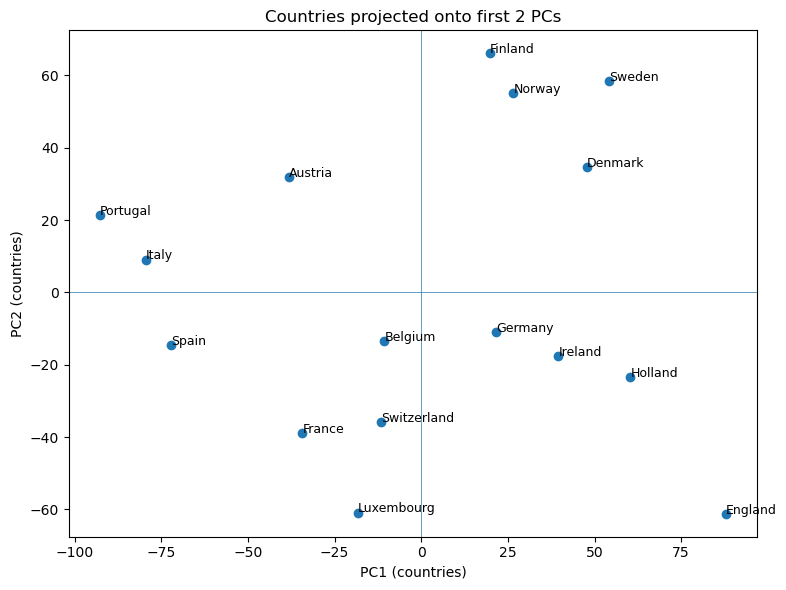

Q1(a) – Explained variance (countries): [2869.13200523 1680.97009326]


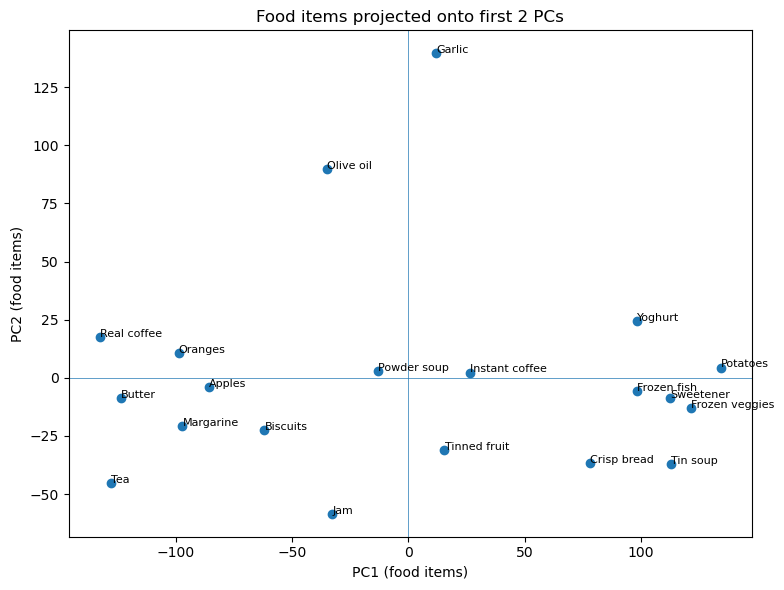

Q1(b) – Explained variance (food items): [8771.15895364 2052.23600608]


In [7]:
######################################################################
# Imports
######################################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import warnings
warnings.filterwarnings("ignore")


plt.rcParams["figure.figsize"] = (8, 6)

######################################################################
# PCA from scratch using SVD
######################################################################
def pca_svd(X, n_components=None):
    """
    Perform PCA via SVD on data matrix X (n_samples x n_features).

    Returns:
        mean          : (n_features,) mean vector
        components    : (n_components, n_features) matrix of principal directions
        explained_var : (n_components,) eigenvalues of covariance
        scores        : (n_samples, n_components) projections of samples on PCs
    """
    X = np.asarray(X, dtype=float)
    # Center the data (subtract mean of each feature)
    mean = X.mean(axis=0)
    X_centered = X - mean

    # SVD: X_centered = U S V^T
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # Principal directions (eigenvectors of covariance) are rows of Vt
    components = Vt  # shape: (min(n_samples, n_features), n_features)

    # Eigenvalues of covariance matrix
    n_samples = X.shape[0]
    explained_variance = (S**2) / (n_samples - 1)

    if n_components is not None:
        components = components[:n_components]
        explained_variance = explained_variance[:n_components]

    # Scores: projections of each sample onto the principal components
    scores = X_centered @ components.T  # (n_samples x n_components)

    return mean, components, explained_variance, scores

######################################################################
# Question 1: PCA for food consumption in European countries
######################################################################

# ---------- Load data ----------
food_path = "food-consumption.csv"  # adjust path if needed
food_df = pd.read_csv(food_path)

# First column = Country names, remaining 20 columns = food items
countries = food_df["Country"].values
food_items = food_df.columns[1:]
X_food = food_df.iloc[:, 1:].values  # shape (16 countries, 20 food items)

# ---------- (a) Countries as data points ----------
# Rows = countries, columns = food items
mean_c, comps_c, evals_c, scores_c = pca_svd(X_food, n_components=2)

pc1_c = scores_c[:, 0]
pc2_c = scores_c[:, 1]

plt.figure()
plt.scatter(pc1_c, pc2_c)
for i, name in enumerate(countries):
    plt.text(pc1_c[i] + 0.05, pc2_c[i] + 0.05, name, fontsize=9)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("PC1 (countries)")
plt.ylabel("PC2 (countries)")
plt.title("Countries projected onto first 2 PCs")
plt.tight_layout()
plt.show()

# You can print explained variance if you want:
print("Q1(a) – Explained variance (countries):", evals_c)

# ---------- (b) Food items as data points ----------
# Now, treat food items as data points, with features = countries.
# So each row = one food item, columns = consumption across countries.
X_items = X_food.T  # shape (20 foods, 16 countries)

mean_f, comps_f, evals_f, scores_f = pca_svd(X_items, n_components=2)

pc1_f = scores_f[:, 0]
pc2_f = scores_f[:, 1]

plt.figure()
plt.scatter(pc1_f, pc2_f)
for i, item in enumerate(food_items):
    plt.text(pc1_f[i] + 0.05, pc2_f[i] + 0.05, item, fontsize=8)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel("PC1 (food items)")
plt.ylabel("PC2 (food items)")
plt.title("Food items projected onto first 2 PCs")
plt.tight_layout()
plt.show()

print("Q1(b) – Explained variance (food items):", evals_f)


Subject 14 training images: ['subject14.gif', 'subject14.glasses.gif', 'subject14.happy.gif', 'subject14.leftlight.gif', 'subject14.noglasses.gif', 'subject14.normal.gif', 'subject14.rightlight.gif', 'subject14.sad.gif', 'subject14.sleepy.gif', 'subject14.wink.gif']
Downsampled image shape: (61, 80)
Data matrix shape (subject 14): (10, 4880)


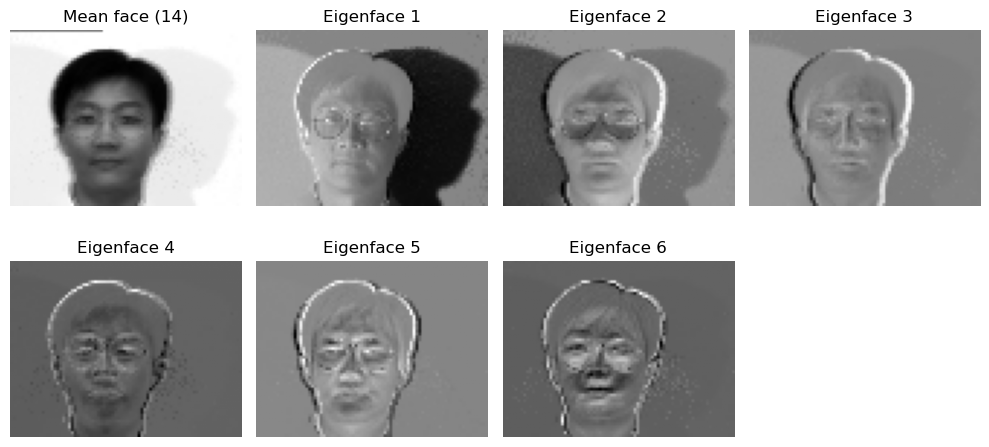

In [8]:
######################################################################
# Question 2: PCA for face recognition (Yale face dataset)
######################################################################

import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# ---------- Read yale faces from folder ----------
faces_dir = "yalefaces"  # folder that contains all subject*.gif files

DOWNSAMPLE = 4  # factor of 4 as requested

# ---------- Helper: load and downsample images for one subject ----------
def load_subject_images(subject_id, base_dir="yalefaces", downsample=4, exclude_test=True):
    """
    Load all images for a given subject id, optionally excluding '*.test.gif',
    and downsample them by the given factor.

    Returns:
        X        : (n_images, n_pixels) data matrix, row = flattened image
        img_shape: (h_down, w_down) shape of each downsampled image
        files    : list of filenames used
    """
    prefix = f"subject{subject_id:02d}"
    all_files = sorted(
        f for f in os.listdir(base_dir)
        if f.startswith(prefix) and f.endswith(".gif")
    )

    if exclude_test:
        files = [f for f in all_files if ".test" not in f]
    else:
        files = all_files

    X_list = []
    img_shape = None

    for fname in files:
        img_path = os.path.join(base_dir, fname)
        img = imageio.imread(img_path).astype(float)  # original resolution
        img_small = img[::downsample, ::downsample]   # downsample by slicing
        if img_shape is None:
            img_shape = img_small.shape
        X_list.append(img_small.ravel())

    X = np.vstack(X_list)  # (n_images, n_pixels)

    return X, img_shape, files

######################################################################
# 2.1: Subject 14 – mean face + first 6 eigenfaces
######################################################################

X14, img_shape14, files14 = load_subject_images(
    14, base_dir=faces_dir, downsample=DOWNSAMPLE, exclude_test=True
)

print("Subject 14 training images:", files14)
print("Downsampled image shape:", img_shape14)
print("Data matrix shape (subject 14):", X14.shape)

# pca_svd from previous question
mean14, comps14, evals14, scores14 = pca_svd(X14)

# Mean face
mean_face14 = mean14.reshape(img_shape14)

# First 6 eigenfaces (principal components)
num_eigenfaces = 6
eigenfaces14 = comps14[:num_eigenfaces]  # shape (6, n_pixels)

# Plot mean face + 6 eigenfaces
plt.figure(figsize=(10, 5))
plt.subplot(2, 4, 1)
plt.imshow(mean_face14, cmap="gray")
plt.title("Mean face (14)")
plt.axis("off")

for i in range(num_eigenfaces):
    plt.subplot(2, 4, i + 2)
    ef_img = eigenfaces14[i].reshape(img_shape14)
    plt.imshow(ef_img, cmap="gray")
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:

######################################################################
# 2.2: Face recognition using first PC for subjects 1 and 14
######################################################################

def first_pc_for_subject(subject_id, base_dir="yalefaces", downsample=4):
    """
    Compute the first principal component for subject i,
    using all their (non-test) images.
    """
    X_subj, img_shape, files = load_subject_images(
        subject_id,
        base_dir=base_dir,
        downsample=downsample,
        exclude_test=True
    )
    mean_subj, comps_subj, evals_subj, scores_subj = pca_svd(X_subj, n_components=1)
    u1 = comps_subj[0]  # first principal direction (eigenface for that subject)
    return mean_subj, u1, img_shape, files

# Compute first PCs for subject 1 and subject 14
mean1, u1_1, shape1, files1 = first_pc_for_subject(
    1, base_dir=faces_dir, downsample=DOWNSAMPLE
)
mean14_pc, u1_14, shape14_pc, _ = first_pc_for_subject(
    14, base_dir=faces_dir, downsample=DOWNSAMPLE
)


print("Subject 1 training images:", files1)

# Load test image for subject 14, downsample and flatten
test_img_path = os.path.join(faces_dir, "subject14.test.gif")
z_full = imageio.imread(test_img_path).astype(float)
z_small = z_full[::DOWNSAMPLE, ::DOWNSAMPLE]
z_vec = z_small.ravel()

# Compute |z^T u_{1,i}| for i in {1, 14}.
# Typically we center z by each subject's mean before projection:
proj1 = abs(np.dot(z_vec - mean1, u1_1))
proj14 = abs(np.dot(z_vec - mean14_pc, u1_14))

print("\nFace recognition using first principal component:")
print(f"|z^T u_1,1|   = {proj1:.4f}")
print(f"|z^T u_1,14|  = {proj14:.4f}")

recognized_subject = 1 if proj1 > proj14 else 14
print(f"Recognized as subject {recognized_subject} (larger absolute projection).")


Subject 1 training images: ['subject01.gif', 'subject01.glasses.gif', 'subject01.happy.gif', 'subject01.leftlight.gif', 'subject01.noglasses.gif', 'subject01.normal.gif', 'subject01.rightlight.gif', 'subject01.sad.gif', 'subject01.sleepy.gif', 'subject01.surprised.gif', 'subject01.wink.gif']

Face recognition using first principal component:
|z^T u_1,1|   = 1734.9564
|z^T u_1,14|  = 561.9728
Recognized as subject 1 (larger absolute projection).


In [13]:
def pcs_for_subject(subject_id, n_components=4, base_dir="yalefaces", downsample=4):
    """
    Compute the first `n_components` principal components for subject i,
    using all their (non-test) images.
    """
    X_subj, img_shape, files = load_subject_images(
        subject_id,
        base_dir=base_dir,
        downsample=downsample,
        exclude_test=True
    )
    mean_subj, comps_subj, evals_subj, scores_subj = pca_svd(X_subj, n_components=n_components)
    # comps_subj has shape (n_components, n_pixels)
    return mean_subj, comps_subj, img_shape, files

# We will use up to 4 PCs
K_MAX = 4
k_values = np.arange(1, K_MAX + 1)

# Compute PCs for subject 1 and subject 14
mean1_k, U1_k, shape1, files1 = pcs_for_subject(
    1, n_components=K_MAX, base_dir=faces_dir, downsample=DOWNSAMPLE
)
mean14_k, U14_k, shape14_k, files14_k = pcs_for_subject(
    14, n_components=K_MAX, base_dir=faces_dir, downsample=DOWNSAMPLE
)

assert shape1 == shape14_k, "Inconsistent image shapes between subjects!"

print("Subject 1 training images:", files1)
print("Subject 14 training images (for PCs):", files14_k)

# Load test image for subject 14, downsample and flatten
test_img_path = os.path.join(faces_dir, "subject14.test.gif")
z_full = imageio.imread(test_img_path).astype(float)
z_small = z_full[::DOWNSAMPLE, ::DOWNSAMPLE]
z_vec = z_small.ravel()

# Center z by each subject's mean before projection
z_centered_1 = z_vec - mean1_k
z_centered_14 = z_vec - mean14_k

print("\nFace recognition using first k principal components:\n")

for k in k_values:
    # Use first k PCs for each subject
    U1_k_sub = U1_k[:k]      # shape (k, n_pixels)
    U14_k_sub = U14_k[:k]    # shape (k, n_pixels)

    # Projection coefficients (k-dimensional) for each subject:
    # coeffs = (z_centered) @ U.T  since rows of U are directions
    coeffs1 = z_centered_1 @ U1_k_sub.T    # shape (k,)
    coeffs14 = z_centered_14 @ U14_k_sub.T # shape (k,)

    # Use the norm of the coefficient vector as similarity score
    norm1 = np.linalg.norm(coeffs1)
    norm14 = np.linalg.norm(coeffs14)

    recognized = 1 if norm1 > norm14 else 14
    if k>0:
        print(f"k = {k}:")
        print(f"  Subject 1  ||projection|| = {norm1:.4f}")
        print(f"  Subject 14 ||projection|| = {norm14:.4f}")
        print(f"  -> Classified as subject {recognized}\n")
        # print(f"k = {k}:")

Subject 1 training images: ['subject01.gif', 'subject01.glasses.gif', 'subject01.happy.gif', 'subject01.leftlight.gif', 'subject01.noglasses.gif', 'subject01.normal.gif', 'subject01.rightlight.gif', 'subject01.sad.gif', 'subject01.sleepy.gif', 'subject01.surprised.gif', 'subject01.wink.gif']
Subject 14 training images (for PCs): ['subject14.gif', 'subject14.glasses.gif', 'subject14.happy.gif', 'subject14.leftlight.gif', 'subject14.noglasses.gif', 'subject14.normal.gif', 'subject14.rightlight.gif', 'subject14.sad.gif', 'subject14.sleepy.gif', 'subject14.wink.gif']

Face recognition using first k principal components:

k = 1:
  Subject 1  ||projection|| = 1734.9564
  Subject 14 ||projection|| = 561.9728
  -> Classified as subject 1

k = 2:
  Subject 1  ||projection|| = 2678.3780
  Subject 14 ||projection|| = 869.3983
  -> Classified as subject 1

k = 3:
  Subject 1  ||projection|| = 2701.4263
  Subject 14 ||projection|| = 1075.0331
  -> Classified as subject 1

k = 4:
  Subject 1  ||proj

## Q4 (3)

In [14]:
import numpy as np

# Parameters
mu0 = 1.0       # true mean of X
z = 10.0        # tail threshold
mu1 = z         # proposal mean for importance sampling
N = 100         # samples per Monte Carlo estimate
n_rep = 500    # number of repeated experiments

rng = np.random.default_rng(seed=100)

def direct_mc_once(mu0, z, N, rng):
    """
    Direct Monte Carlo estimate:
    X ~ N(mu0, 1), estimate P(X >= z) by sample frequency.
    """
    X = rng.normal(loc=mu0, scale=1.0, size=N)
    return np.mean(X >= z)


def importance_sampling_once(mu0, mu1, z, N, rng):
    """
    Importance sampling estimate:
    Sample X ~ N(mu1, 1), weight by f(X)/g(X), where
        f = N(mu0, 1), g = N(mu1, 1).
    Estimator: (1/N) * sum I{X >= z} * w_i
    """
    X = rng.normal(loc=mu1, scale=1.0, size=N)
    
    # Log weight: log(f/g)
    # f/g = exp( x*(mu0 - mu1) + 0.5*(mu1**2 - mu0**2) )
    w = np.exp(X * (mu0 - mu1) + 0.5 * (mu1**2 - mu0**2))
    
    return np.mean((X >= z) * w)


# Arrays to store the 500 estimates
direct_estimates = np.zeros(n_rep)
is_estimates = np.zeros(n_rep)

for k in range(n_rep):
    direct_estimates[k] = direct_mc_once(mu0, z, N, rng)
    is_estimates[k] = importance_sampling_once(mu0, mu1, z, N, rng)

# Empirical means and variances
direct_mean = np.mean(direct_estimates)
direct_var = np.var(direct_estimates, ddof=1)

is_mean = np.mean(is_estimates)
is_var = np.var(is_estimates, ddof=1)

print("Direct MC:")
print(f"  Mean estimate      = {direct_mean:.6e}")
print(f"  Empirical variance = {direct_var:.6e}")

print("\nImportance Sampling:")
print(f"  Mean estimate      = {is_mean:.6e}")
print(f"  Empirical variance = {is_var:.6e}")


Direct MC:
  Mean estimate      = 0.000000e+00
  Empirical variance = 0.000000e+00

Importance Sampling:
  Mean estimate      = 1.116592e-19
  Empirical variance = 1.228066e-39


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import pairwise_distances
from fancyimpute import SoftImpute

movie = pd.read_excel("movie.xlsx", header=None)

movie = movie.drop(movie.columns[1], axis=1)
movie = movie.drop(movie.index[0]).reset_index(drop=True)

labels = movie.iloc[:, 0]

idx_fav_genres    = labels[labels == "Favourite Genres"].index[0]
idx_movie_ratings = labels[labels == "Movie Ratings"].index[0]

meta_rows   = movie.iloc[:idx_movie_ratings + 1, :] # selects
ratings_raw = movie.iloc[idx_movie_ratings + 1:, :] # 0-5

ratings_raw = ratings_raw.set_index(ratings_raw.columns[0])
R = ratings_raw.apply(pd.to_numeric, errors="coerce")   
print("R shape:", R.shape)


user_cols = R.columns  

gender = meta_rows.iloc[0, 1:].rename("Gender")
colour = meta_rows.iloc[1, 1:].rename("Colour")

genre_pref_block = movie.iloc[idx_fav_genres + 1 : idx_movie_ratings, :]
genre_names = genre_pref_block.iloc[:, 0].values
genre_pref = genre_pref_block.iloc[:, 1:].T   # users × genres
genre_pref.columns = genre_names
genre_pref.index = user_cols

cat_df = pd.DataFrame(
    {"Gender": gender.values, "Colour": colour.values},
    index=user_cols
).fillna("Unknown")

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_ohe_arr = ohe.fit_transform(cat_df)
cat_ohe = pd.DataFrame(
    cat_ohe_arr,
    index=user_cols,
    columns=ohe.get_feature_names_out(cat_df.columns)
)

user_features = pd.concat([cat_ohe, genre_pref], axis=1)
user_features = user_features.dropna(axis=1, how="all").fillna(0.0)

print("user_features shape:", user_features.shape)


moviegenres_df = pd.read_excel("MovieGenres.xlsx", header=None)
moviegenres_df = moviegenres_df.drop(moviegenres_df.columns[1], axis = 1)
moviegenres_df.columns = ['Movie', "Genres"]

genre_dummies = moviegenres_df["Genres"].str.get_dummies(sep=", ").astype(float)
genre_dummies.index = moviegenres_df["Movie"]

item_features = genre_dummies.loc[R.index]
print("item_features shape:", item_features.shape)


def similarity_from_distance(X, metric="euclidean"):
    D = pairwise_distances(X, metric=metric)
    return np.exp(-(D ** 2))

def user_based_predict(R, sim, zero_is_missing=True):
    R_values = R.values.astype(float)

    if zero_is_missing:
        mask = (R_values != 0)
        R_filled = np.where(mask, R_values, 0.0)
    else:
        mask = ~np.isnan(R_values)
        R_filled = np.nan_to_num(R_values, nan=0.0)

    S = sim.copy()
    np.fill_diagonal(S, 0.0)   

    num = R_filled @ S.T                
    den = mask.astype(float) @ S.T     

    den = np.where(den == 0, 1, den)  
    return num / den

def item_based_predict(R, sim_items, zero_is_missing=True):
    R_values = R.values.astype(float)

    if zero_is_missing:
        mask = (R_values != 0)
        R_filled = np.where(mask, R_values, 0.0)
    else:
        mask = ~np.isnan(R_values)
        R_filled = np.nan_to_num(R_values, nan=0.0)

    S = sim_items.copy()
    np.fill_diagonal(S, 0.0)

    num = S @ R_filled             
    den = S @ mask.astype(float)    

    den = np.where(den == 0, 1, den)
    return num / den

def build_recommendation_df(R, preds, k=5):
    pred_values = preds.values if isinstance(preds, pd.DataFrame) else np.asarray(preds)
    R_values = R.values.astype(float)

    movies = R.index.to_numpy()
    users  = R.columns.to_numpy()

    rows = []

    for j, user in enumerate(users):
        user_pred = pred_values[:, j]  # predicted rating for all movies for this user

        # rank movies by predicted rating (descending)
        top_idx = np.argsort(-user_pred)[:k]

        row = [user]
        for idx in top_idx:
            movie_name = movies[idx]
            score_to_show = float(user_pred[idx])  # ALWAYS predicted score

            row.append(movie_name)
            row.append(score_to_show)

        rows.append(row)

    # create column names
    cols = ["name"]
    for i in range(1, k + 1):
        cols.append(f"recommended_movie_{i}")
        cols.append(f"score_{i}")

    return pd.DataFrame(rows, columns=cols)


user_sims = {
    "L2": similarity_from_distance(user_features.values, metric="euclidean"),
    "L1": similarity_from_distance(user_features.values, metric="manhattan"),
    "Hamming": similarity_from_distance(user_features.values, metric="hamming"),
}

dfs_to_write = {}

for metric_name, sim in user_sims.items():
    preds = user_based_predict(R, sim, zero_is_missing=True)
    df = build_recommendation_df(R, preds, k=5)
    sheet_name = f"User_{metric_name}"
    dfs_to_write[sheet_name] = df
    print(f"Built user-based sheet: {sheet_name}")


item_sims = {
    "L2": similarity_from_distance(item_features.values, metric="euclidean"),
    "L1": similarity_from_distance(item_features.values, metric="manhattan"),
    "Hamming": similarity_from_distance(item_features.values, metric="hamming"),
}

for metric_name, sim in item_sims.items():
    preds = item_based_predict(R, sim, zero_is_missing=True)
    df = build_recommendation_df(R, preds, k=5)
    sheet_name = f"Item_{metric_name}"
    dfs_to_write[sheet_name] = df
    print(f"Built item-based sheet: {sheet_name}")


R_mc_input = R.astype(float).copy()

soft_imputer = SoftImpute()
R_completed = soft_imputer.fit_transform(R_mc_input.values)

df_mc = build_recommendation_df(R, R_completed, k=5)

for metric_name in ["L2", "L1", "Hamming"]:
    sheet_name = f"MC_{metric_name}"
    dfs_to_write[sheet_name] = df_mc.copy()
    print(f"Built matrix-completion sheet: {sheet_name}")

output_file = "movie_recommendations_9tabs.xlsx"

with pd.ExcelWriter(output_file) as writer:  
    for sheet_name, df in dfs_to_write.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Saved all recommendations to:", output_file)

R shape: (20, 46)
user_features shape: (46, 21)
item_features shape: (20, 7)
Built user-based sheet: User_L2
Built user-based sheet: User_L1
Built user-based sheet: User_Hamming
Built item-based sheet: Item_L2
Built item-based sheet: Item_L1
Built item-based sheet: Item_Hamming
[SoftImpute] Max Singular Value of X_init = 67.040454
[SoftImpute] Iter 1: observed MAE=0.156857 rank=20
[SoftImpute] Iter 2: observed MAE=0.156857 rank=20
[SoftImpute] Iter 3: observed MAE=0.156857 rank=20
[SoftImpute] Iter 4: observed MAE=0.156857 rank=20
[SoftImpute] Iter 5: observed MAE=0.156857 rank=20
[SoftImpute] Iter 6: observed MAE=0.156857 rank=20
[SoftImpute] Iter 7: observed MAE=0.156857 rank=20
[SoftImpute] Iter 8: observed MAE=0.156857 rank=20
[SoftImpute] Iter 9: observed MAE=0.156857 rank=20
[SoftImpute] Iter 10: observed MAE=0.156857 rank=20
[SoftImpute] Iter 11: observed MAE=0.156857 rank=20
[SoftImpute] Iter 12: observed MAE=0.156857 rank=20
[SoftImpute] Iter 13: observed MAE=0.156857 rank=20


/var/folders/jz/84tjgdn52kg4xwv8hd8bhz_m0000gn/T/ipykernel_48799/1486389536.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  user_features = user_features.dropna(axis=1, how="all").fillna(0.0)
/Users/aramesh/exit/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aramesh/exit/lib/python3.13/site-packages/fancyimpute/solver.py:55: UserWarning: Input matrix is not missing any values
  warnings.warn("Input matrix is not missing any values")
/Users/aramesh/exit/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warni